## Custom Object Detection with YOLOv11

## Force re-authentication

## Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Installing Ultralytics

In [2]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.3.193 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 39.1/112.6 GB disk)


## Data Preparation

In [3]:
%cd /content/drive/MyDrive/yolo11zip

/content/drive/MyDrive/yolo11zip


In [ ]:
#!unzip /content/drive/MyDrive/yolo11zip/Yolo11.zip

## Using the command Line Interface

## starting The Training Procedure

In [4]:
# Predict using a pretrained YOLO model (e.g., YOLO11n) on an image
!yolo train model=yolo11n.pt data="/content/drive/MyDrive/yolo11zip/Yolo11/data.yaml" epochs=10 imgsz=640


Ultralytics 8.3.193 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/yolo11zip/Yolo11/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, 

In [5]:
!yolo val model=yolo11n.pt data=coco8.yaml

Ultralytics 8.3.193 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

WARNING ⚠️ Dataset 'coco8.yaml' images not found, missing path '/content/datasets/coco8/images/val'
Unzipping /content/datasets/coco8.zip to /content/datasets/coco8...: 100% ━━━━━━━━━━━━ 25/25 5.0Kfiles/s 0.0s
Dataset download success ✅ (0.3s), saved to /content/datasets

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1887.0±923.4 MB/s, size: 54.0 KB)
val: Scanning /content/datasets/coco8/labels/val... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 785.0it/s 0.0s
val: New cache created: /content/datasets/coco8/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.6it/s 0.3s
                   all          4         17       0.57       0.85      0.847      0.632
                person          3         10      0.557        0.6      

## Validating the Trained Model

In [7]:
!yolo val model="/content/drive/MyDrive/yolo11zip/runs/detect/train/weights/best.pt" data="/content/drive/MyDrive/yolo11zip/Yolo11/data.yaml"

Ultralytics 8.3.193 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.2 ms, read: 13.2±4.9 MB/s, size: 27.4 KB)
val: Scanning /content/drive/MyDrive/yolo11zip/Yolo11/valid/labels.cache... 576 images, 238 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 576/576 7.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 36/36 4.4it/s 8.2s
                   all        576        400      0.917      0.909      0.941      0.738
                 Paper        132        139      0.929      0.914      0.947      0.742
                  Rock        121        141       0.89      0.929      0.933      0.718
              Scissors        116        120      0.933      0.883      0.945      0.752
Speed: 0.5ms preprocess, 4.5ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to /content/drive/M

## Visualizaing the predicted image function

In [8]:
import cv2
from google.colab.patches import cv2_imshow

def show_images(image_path):
  """
  Function to display images
  """
  image = cv2.imread(image_path)
  if image is None:
    print("Error: Unable to read the image.")
    return
  cv2_imshow(image)


## Inferencing with the trained model

In [9]:
!yolo predict model="/content/drive/MyDrive/yolo11zip/runs/detect/train/weights/best.pt" source="/content/drive/MyDrive/yolo11zip/Yolo11/train/images/0001_png.rf.5e009a9ec5fbf7a8e856ba7f413996af.jpg"

Ultralytics 8.3.193 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs

image 1/1 /content/drive/MyDrive/yolo11zip/Yolo11/train/images/0001_png.rf.5e009a9ec5fbf7a8e856ba7f413996af.jpg: 640x640 2 Rocks, 44.6ms
Speed: 4.6ms preprocess, 44.6ms inference, 153.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/drive/MyDrive/yolo11zip/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


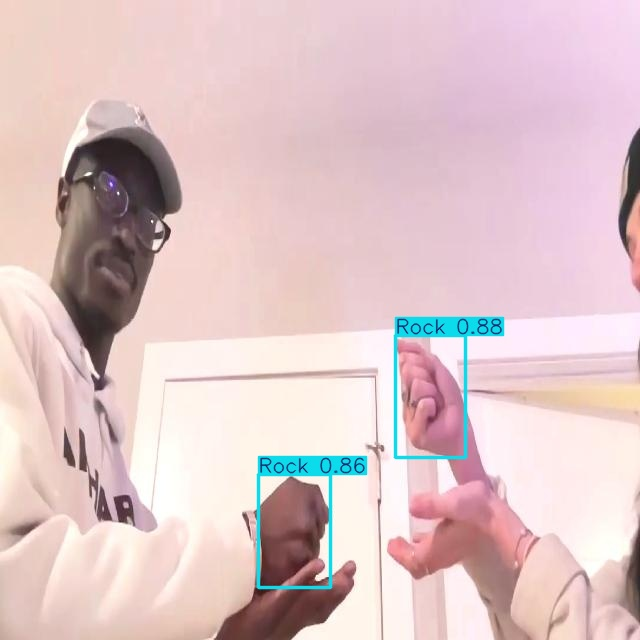

In [10]:
show_images("/content/drive/MyDrive/yolo11zip/runs/detect/predict/0001_png.rf.5e009a9ec5fbf7a8e856ba7f413996af.jpg")

In [ ]:
!cd runs/detect/predict

##  Export

Export a YOLO11 model to any supported format below with the `format` argument, i.e. `format=onnx`. See [YOLO11 Export Docs](https://docs.ultralytics.com/modes/export/) for more information.

- 💡 ProTip: Export to [ONNX](https://docs.ultralytics.com/integrations/onnx/) or [OpenVINO](https://docs.ultralytics.com/integrations/openvino/) for up to 3x CPU speedup.  
- 💡 ProTip: Export to [TensorRT](https://docs.ultralytics.com/integrations/tensorrt/) for up to 5x GPU speedup.

| Format                                                                   | `format` Argument | Model                     | Metadata | Arguments                                                            |
|--------------------------------------------------------------------------|-------------------|---------------------------|----------|----------------------------------------------------------------------|
| [PyTorch](https://pytorch.org/)                                          | -                 | `yolo11n.pt`              | ✅        | -                                                                    |
| [TorchScript](https://docs.ultralytics.com/integrations/torchscript)     | `torchscript`     | `yolo11n.torchscript`     | ✅        | `imgsz`, `optimize`, `batch`                                         |
| [ONNX](https://docs.ultralytics.com/integrations/onnx)                   | `onnx`            | `yolo11n.onnx`            | ✅        | `imgsz`, `half`, `dynamic`, `simplify`, `opset`, `batch`             |
| [OpenVINO](https://docs.ultralytics.com/integrations/openvino)           | `openvino`        | `yolo11n_openvino_model/` | ✅        | `imgsz`, `half`, `dynamic`, `int8`, `batch`, `data`                  |
| [TensorRT](https://docs.ultralytics.com/integrations/tensorrt)           | `engine`          | `yolo11n.engine`          | ✅        | `imgsz`, `half`, `dynamic`, `simplify`, `workspace`, `int8`, `batch`, `data` |
| [CoreML](https://docs.ultralytics.com/integrations/coreml)               | `coreml`          | `yolo11n.mlpackage`       | ✅        | `imgsz`, `half`, `int8`, `nms`, `batch`                              |
| [TF SavedModel](https://docs.ultralytics.com/integrations/tf-savedmodel) | `saved_model`     | `yolo11n_saved_model/`    | ✅        | `imgsz`, `keras`, `int8`, `batch`                                    |
| [TF GraphDef](https://docs.ultralytics.com/integrations/tf-graphdef)     | `pb`              | `yolo11n.pb`              | ❌        | `imgsz`, `batch`                                                     |
| [TF Lite](https://docs.ultralytics.com/integrations/tflite)              | `tflite`          | `yolo11n.tflite`          | ✅        | `imgsz`, `half`, `int8`, `batch`, `data`                             |
| [TF Edge TPU](https://docs.ultralytics.com/integrations/edge-tpu)        | `edgetpu`         | `yolo11n_edgetpu.tflite`  | ✅        | `imgsz`                                                              |
| [TF.js](https://docs.ultralytics.com/integrations/tfjs)                  | `tfjs`            | `yolo11n_web_model/`      | ✅        | `imgsz`, `half`, `int8`, `batch`                                     |
| [PaddlePaddle](https://docs.ultralytics.com/integrations/paddlepaddle)   | `paddle`          | `yolo11n_paddle_model/`   | ✅        | `imgsz`, `batch`                                                     |
| [MNN](https://docs.ultralytics.com/integrations/mnn)                     | `mnn`             | `yolo11n.mnn`             | ✅        | `imgsz`, `batch`, `int8`, `half`                                     |
| [NCNN](https://docs.ultralytics.com/integrations/ncnn)                   | `ncnn`            | `yolo11n_ncnn_model/`     | ✅        | `imgsz`, `half`, `batch`                                             |
| [IMX500](https://docs.ultralytics.com/integrations/sony-imx500)          | `imx`             | `yolov8n_imx_model/`      | ✅        | `imgsz`, `int8`, `data`                                              |
| [RKNN](https://docs.ultralytics.com/integrations/rockchip-rknn)          | `rknn`            | `yolo11n_rknn_model/`     | ✅        | `imgsz`, `batch`, `name`                                             |

## Exporting in onnx for faster inferencing speeds on cpu

In [12]:
!yolo export model="/content/drive/MyDrive/yolo11zip/runs/detect/train/weights/best.pt" format=onnx

Ultralytics 8.3.193 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon 2.00GHz)
YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/yolo11zip/runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (5.2 MB)

ONNX: starting export with onnx 1.19.0 opset 19...
ONNX: slimming with onnxslim 0.1.65...
ONNX: export success ✅ 1.6s, saved as '/content/drive/MyDrive/yolo11zip/runs/detect/train/weights/best.onnx' (10.1 MB)

Export complete (2.1s)
Results saved to /content/drive/MyDrive/yolo11zip/runs/detect/train/weights
Predict:         yolo predict task=detect model=/content/drive/MyDrive/yolo11zip/runs/detect/train/weights/best.onnx imgsz=640  
Validate:        yolo val task=detect model=/content/drive/MyDrive/yolo11zip/runs/detect/train/weights/best.onnx imgsz=640 data=/content/drive/MyDrive/yolo11zip/Yolo11/data.yaml  
Visualize:       https://netron.app
💡 Learn 

## Exporting in TensorRT for faster inferencing speeds on cpu

In [13]:
!yolo export model=yolo11n.pt format=engine

WARNING ⚠️ TensorRT requires GPU export, automatically assigning device=0
Ultralytics 8.3.193 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

PyTorch: starting from 'yolo11n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (5.4 MB)
requirements: Ultralytics requirement ['onnxruntime-gpu'] not found, attempting AutoUpdate...

requirements: AutoUpdate success ✅ 4.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.19.0 opset 19...
ONNX: slimming with onnxslim 0.1.65...
ONNX: export success ✅ 7.2s, saved as 'yolo11n.onnx' (10.2 MB)
requirements: Ultralytics requirement ['tensorrt>7.0.0,!=10.1.0'] not found, attempting AutoUpdate...

requirements: AutoUpdate success ✅ 67.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


TensorRT: starting export with Tens

## Python Usage

In [14]:
from ultralytics import YOLO

model = YOLO('yolo11s.pt')

## Use the model
results = model.train(data="/content/drive/MyDrive/yolo11zip/Yolo11/data.yaml",epochs=1)## Train the model
#results = model.val()## Validate the model
#results = model("/content/drive/MyDrive/yolo11zip/Yolo11/train/images/0001_png.rf.5e009a9ec5fbf7a8e856ba7f413996af.jpg")## Predict with the model
#results = model.export(format="onnx")## Export the model onnx
#results = model.export(format="engine")## Export the model engine




Ultralytics 8.3.193 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/yolo11zip/Yolo11/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, 

In [15]:
from ultralytics import YOLO
model1=YOLO("/content/drive/MyDrive/yolo11zip/runs/detect/train2/weights/best.pt")
source=""
results = model1("/content/drive/MyDrive/yolo11zip/Yolo11/train/images/0001_png.rf.5e009a9ec5fbf7a8e856ba7f413996af.jpg")## Predict with the model


image 1/1 /content/drive/MyDrive/yolo11zip/Yolo11/train/images/0001_png.rf.5e009a9ec5fbf7a8e856ba7f413996af.jpg: 640x640 2 Papers, 3 Rocks, 1 Scissors, 15.6ms
Speed: 2.2ms preprocess, 15.6ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
